## 7. Conclusion

Blending SARIMA with the regularized macro model (the Ensemble) edges out either one alone on the shared grid, while Elastic Net on its own does not beat plain SARIMA in pooled RMSE. That is real, if modest, evidence that structure helps at this sample size without over-engineering the model. Against the RBA's own published headline forecast, scored on the same origins and horizons (each against its own actual), the models are comparable rather than demonstrably better or worse: the Ensemble's pooled RMSE is 1.640 against the RBA's 1.690, but the paired-bootstrap interval for that gap includes zero ([§5 Evaluation](05_evaluation)). The SVAR/scenario layer adds a
second, separate kind of value (*why* a shock might move CPI) at the honestly-stated cost
of two systems that still fail their own residual diagnostics.

In [1]:
import sys, warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd()
for _ in range(4):
    if (PROJECT_ROOT / "reports").is_dir() and (PROJECT_ROOT / "data").is_dir():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

INK, PAPER, ACCENT, ACCENT_SOFT, HIGHLIGHT, GRID = (
    "#16211c", "#f7f8f5", "#1f6f66", "#bfe3dd", "#a8691f", "#d9ddd6",
)
BLUE, PLUM, MUTED, ALERT = "#5b6f8f", "#8a4f8a", "#9aa79f", "#c0392b"
plt.rcParams.update({
    "figure.facecolor": PAPER, "axes.facecolor": PAPER, "axes.edgecolor": GRID,
    "axes.labelcolor": INK, "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "font.size": 11, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
})

import matplotlib.dates as mdates

def year_axis(ax, step=5):
    ax.xaxis.set_major_locator(mdates.YearLocator(step))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

CURATED = PROJECT_ROOT / "data" / "curated" / "quarterly_macro_features.csv"
TABLEAU = PROJECT_ROOT / "reports" / "tableau"

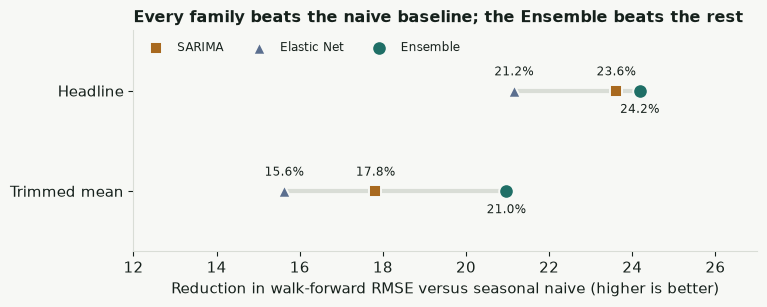

In [3]:
mc = pd.read_csv(TABLEAU / "model_comparison.csv")
naive = mc[mc["model"] == "seasonal_naive"].set_index("target")["rmse"]
mc = mc[mc["model"] != "seasonal_naive"].copy()
mc["gain"] = (1 - mc["rmse"] / mc["target"].map(naive)) * 100

families = [("sarima", "SARIMA", HIGHLIGHT, "s"), ("elastic_net", "Elastic Net", BLUE, "^"), ("ensemble", "Ensemble", ACCENT, "o")]
targets = ["Headline", "Trimmed mean"]

fig, ax = plt.subplots(figsize=(7.8, 3.2))
for row, target in enumerate(targets[::-1]):
    sub = mc[mc["target"] == target].set_index("model")
    ax.plot([sub["gain"].min(), sub["gain"].max()], [row, row], color=GRID, linewidth=3, zorder=1)
    for key, label, color, marker in families:
        g = sub.loc[key, "gain"]
        ax.scatter([g], [row], s=110 if key == "ensemble" else 80, color=color, marker=marker, edgecolor=PAPER,
                   linewidth=1.4, zorder=3, label=label if row == 0 else None)
        ax.annotate(f"{g:.1f}%", (g, row), xytext=(0, -16 if key == "ensemble" else 11), textcoords="offset points",
                    ha="center", fontsize=8.5)
ax.set_yticks(range(len(targets)), targets[::-1])
ax.set_ylim(-0.6, len(targets) - 0.4)
ax.set_xlim(12, 27)
ax.set_xlabel("Reduction in walk-forward RMSE versus seasonal naive (higher is better)")
ax.set_title("Every family beats the naive baseline; the Ensemble beats the rest", loc="left", fontsize=11.5, fontweight="bold")
ax.legend(frameon=False, fontsize=8.5, loc="upper left", ncol=3)
ax.grid(False)
fig.tight_layout()
plt.show()

**Try it yourself:**
- Live API docs: the Cloud Run `/docs` endpoint (see `README.md` for the current URL)
- `streamlit run app/streamlit_app.py`: the interactive demo (live forecast, Ensemble path reveal, scenario engine, RBA call)
- This book, rebuilt from its saved outputs: `jupyter-book build book/australian_cpi_forecasting`. To re-run the analysis yourself, use `notebooks/EDA.ipynb`